In [1]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# since engineering values are a range not just dual class or binary ans


# I AM GOD
np.random.seed(42)
true_mu=30  # true mean concr str in mpa
true_sigma=4
cube_tests = np.random.normal(loc=true_mu, scale=true_sigma, size=50)

print(f"Sample Mean: {cube_tests.mean():.2f} MPa")
print(f"Sample Std:  {cube_tests.std():.2f} MPa")
# sample bias

Sample Mean: 29.10 MPa
Sample Std:  3.70 MPa


In [ ]:
# I AM ENGINEER - CONCRETE STRENGTH (30 MPa Context)

with pm.Model() as str_model:
    # Scientific Intent: Estimate concrete quality.
    # Use distinct names to avoid namespace collision with Tunnel Stress.
    mu_cube = pm.Normal("mu_cube", mu=30, sigma=10)
    sigma_cube = pm.HalfNormal("sigma_cube", sigma=15)

    y = pm.Normal("y", mu=mu_cube, sigma=sigma_cube, observed=cube_tests)
    trace_cube = pm.sample(2000, tune=1000, random_seed=42)

az.plot_posterior(trace_cube, var_names=["mu_cube", "sigma_cube"],
                 ref_val={"mu_cube": [{"ref_val": true_mu}],
                           "sigma_cube": [{"ref_val": true_sigma}]})
plt.suptitle("Posterior: Concrete Strength (mu_cube ~ 30 MPa)")
plt.tight_layout()
plt.show()

*   **Scenario:** You measured the in-situ horizontal stress at 15 locations in a tunnel using hydraulic fracturing.
*   **Data:** `stress_data = np.random.normal(loc=12.0, scale=3.0, size=15)` (True: 12 MPa, Sigma: 3 MPa)
*   **Priors:** `mu ~ Normal(10, 5)`, `sigma ~ HalfNormal(5)`
*   **Task:** Estimate the posterior of mu and sigma.

In [ ]:
# I AM TUNNEL ENGINEER - IN-SITU STRESS (12 MPa Context)

stress_data = np.random.normal(loc=12.0, scale=3.0, size=15)

with pm.Model() as tunn_model:
    # Scientific Intent: Site-specific stress.
    mu_tunn = pm.Normal("mu_tunn", mu=10, sigma=5)
    sigma_tunn = pm.HalfNormal("sigma_tunn", sigma=5)

    likelihood = pm.Normal("likelihood", mu=mu_tunn, sigma=sigma_tunn, observed=stress_data)
    trace_tunn = pm.sample(1000, tune=1000, random_seed=42)

az.plot_posterior(
    data=trace_tunn,
    var_names=["mu_tunn", "sigma_tunn"],
    hdi_prob=0.95,
    ref_val=[12.0, 3.0]
)
plt.suptitle("Posterior: Tunnel Stress (mu_tunn ~ 12 MPa)")
plt.show()

In [ ]:
# Outlier Analysis (Concrete Context)

cube_tests_corrupted = np.append(cube_tests, [5.0])

with pm.Model() as corrupt_model:
    mu_cube = pm.Normal("mu_cube", mu=30, sigma=10)
    sigma_cube = pm.HalfNormal("sigma_cube", sigma=15)

    y = pm.Normal("y", mu=mu_cube, sigma=sigma_cube, observed=cube_tests_corrupted)
    trace_corrupted = pm.sample(2000, tune=1000, cores=1, random_seed=42)

# Compare clean vs corrupted (using correct unique traces)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
az.plot_posterior(trace_cube, var_names=["mu_cube"], ax=axes[0])
axes[0].set_title(f"Clean Concrete (n={len(cube_tests)})")

az.plot_posterior(trace_corrupted, var_names=["mu_cube"], ax=axes[1])
axes[1].set_title(f"Corrupted Concrete (+5 MPa outlier)")

plt.tight_layout()
plt.show()

# Print the shift using fixed variable names
clean_mu_val = trace_cube.posterior["mu_cube"].values.flatten().mean()
corrupt_mu_val = trace_corrupted.posterior["mu_cube"].values.flatten().mean()
print(f"Clean mu_cube: {clean_mu_val:.2f} MPa")
print(f"Corrupted mu_cube: {corrupt_mu_val:.2f} MPa")
print(f"Shift: {clean_mu_val - corrupt_mu_val:.2f} MPa")


# hdi internval larger on the corrupt one

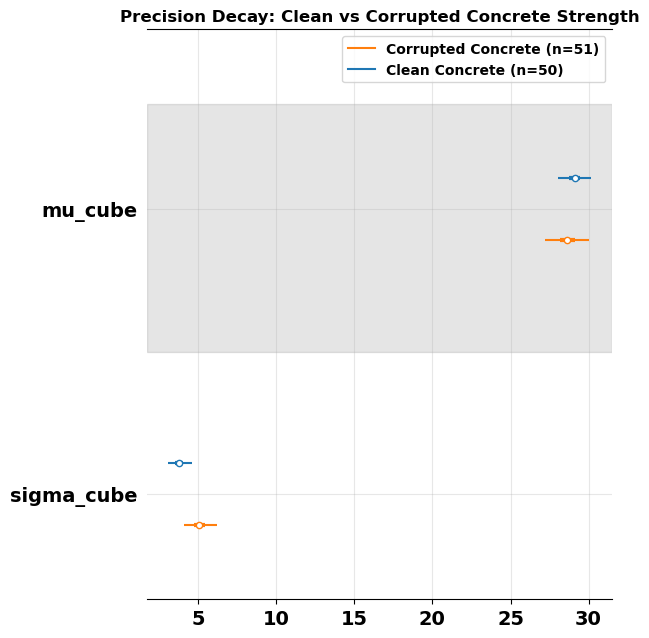

In [5]:
# Forest Plot: Corrected Forensic Comparison
# Using trace_cube (Clean Concrete) and trace_corrupted (Dirty Concrete)

az.plot_forest(
    [trace_cube, trace_corrupted],
    model_names=["Clean Concrete (n=50)", "Corrupted Concrete (n=51)"],
    var_names=["mu_cube", "sigma_cube"],
    combined=True,
    hdi_prob=0.95
)
plt.title("Precision Decay: Clean vs Corrupted Concrete Strength")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Sparse Model Study (n=5)

cube_tests_sparse = cube_tests[:5]

with pm.Model() as sparse_model:
    mu_cube = pm.Normal("mu_cube", mu=30, sigma=10)
    sigma_cube = pm.HalfNormal("sigma_cube", sigma=10)
    y = pm.Normal("y", mu=mu_cube, sigma=sigma_cube, observed=cube_tests_sparse)
    trace_sparse = pm.sample(2000, tune=1000, cores=1, random_seed=42)

# Compare n=50 vs n=5 using explicit unique trace names
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# n=50: High Certainty (Clean Concrete)
az.plot_posterior(trace_cube, var_names=["mu_cube"], ax=axes[0])
axes[0].set_title(f"n=50 Concrete (Clean)")

# n=5: Low Certainty (Sparse Concrete)
az.plot_posterior(trace_sparse, var_names=["mu_cube"], ax=axes[1])
axes[1].set_title(f"n=5 Concrete (Sparse)")

plt.suptitle("Impact of Sample Size on Forensic Certainty (Explicit Trace Mapping)")
plt.tight_layout()
plt.show()